# Análisis de Marketing — Alojamientos Turísticos
## Sprint 3 — ¿Qué ciudades y barrios presentan mayor potencial de optimización?

**Pregunta de negocio:** ¿Qué ciudad y barrios presentan un potencial de mayor optimización considerando las reseñas, la puntuación de la zona y la disponibilidad mínima/máxima de noches?

**Metodología:** Distancia euclidiana al alojamiento ideal. Para cada alojamiento se calcula cuánto se aleja de un alojamiento hipotético con los mejores valores posibles en las cuatro dimensiones.

**Alojamiento ideal definido por negocio:**
- `review_scores_rating_clean` = 100 — máxima calidad percibida
- `review_scores_location` = 100 — máxima valoración de ubicación
- `minimum_nights` = 2 — turismo de fin de semana (mediana del dataset)
- `maximum_nights` = 31 — límite entre alquiler turístico y de temporada

## 0. Configuración global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler
import os

# ── Dataset ───────────────────────────────────────────────────────────────────
#df = pd.read_csv('marketing_cleaned_tourist_accommodation_04_05.csv')
df = pd.read_csv("../Data/marketing_cleaned_tourist_accommodation_04_05.csv")

# ── Paleta de colores ─────────────────────────────────────────────────────────
AZUL_OSCURO    = '#1A4E6E'
AZUL_PRINCIPAL = '#2C7BB6'
TURQUESA       = '#74C2C9'
AZUL_CLARO     = '#B8DDE4'
FONDO_SUAVE    = '#E8F4F7'
GRIS_TEXTO     = '#4A4A4A'
GRIS_GRID      = '#E0E0E0'
NARANJA        = '#E07B39'
ROJO           = '#6a5acd'

# ── Carpeta de salida ─────────────────────────────────────────────────────────
OUTPUT_DIR = 'graficos_sprint3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Variables y parámetros ────────────────────────────────────────────────────
FEATURES = ['review_scores_rating_clean', 'review_scores_location',
            'minimum_nights', 'maximum_nights']
IDEAL    = [100, 100, 2, 31]
MIN_N    = 20   # mínimo de alojamientos por barrio

# ── Limpieza ──────────────────────────────────────────────────────────────────
df['neighbourhood_name_clean'] = (df['neighbourhood_name_clean']
                                   .str.encode('latin1', errors='ignore')
                                   .str.decode('utf-8', errors='ignore')
                                   .str.strip().str.lower())

for c in FEATURES:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=FEATURES).copy()

print(f"Dataset limpio: {len(df):,} registros | {df['city'].nunique()} ciudades")
print(f"Nulos tras limpieza: {df[FEATURES].isnull().sum().sum()}")

Dataset limpio: 7,010 registros | 8 ciudades
Nulos tras limpieza: 0


## 1. Cálculo de distancias al ideal

In [2]:
# ── Normalización MinMaxScaler ────────────────────────────────────────────────
scaler  = MinMaxScaler()
X       = scaler.fit_transform(df[FEATURES])
ideal_n = scaler.transform([IDEAL])

# Diferencias normalizadas
diffs = X - ideal_n

# ── 5 columnas de distancia ───────────────────────────────────────────────────
df['dist_rating']     = np.abs(diffs[:, 0]).round(4)
df['dist_location']   = np.abs(diffs[:, 1]).round(4)
df['dist_min_nights'] = np.abs(diffs[:, 2]).round(4)
df['dist_max_nights'] = np.abs(diffs[:, 3]).round(4)
df['dist_total']      = np.sqrt((diffs ** 2).sum(axis=1)).round(4)

print("=== ESTADÍSTICAS DE LAS 5 COLUMNAS DE DISTANCIA ===")
dist_cols = ['dist_rating', 'dist_location', 'dist_min_nights',
             'dist_max_nights', 'dist_total']
print(df[dist_cols].describe().round(4))

=== ESTADÍSTICAS DE LAS 5 COLUMNAS DE DISTANCIA ===
       dist_rating  dist_location  dist_min_nights  dist_max_nights  \
count    7010.0000      7010.0000        7010.0000        7010.0000   
mean        0.1009         0.0570           0.0025           0.6382   
std         0.1148         0.0962           0.0150           0.4423   
min         0.0000         0.0000           0.0000           0.0000   
25%         0.0250         0.0000           0.0000           0.0258   
50%         0.0750         0.0000           0.0009           0.9733   
75%         0.1375         0.1250           0.0009           0.9733   
max         1.0000         1.0000           0.9991           0.9733   

       dist_total  
count   7010.0000  
mean       0.6856  
std        0.4110  
min        0.0000  
25%        0.1858  
50%        0.9735  
75%        0.9833  
max        1.7168  


C:\Users\windows10\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Las 5 columnas calculan cuánto se aleja cada alojamiento del ideal en cada dimensión. Una distancia de 0 significa que el alojamiento está en el valor ideal. Cuanto mayor la distancia, mayor el potencial de mejora en esa dimensión.

## 2. Métricas globales del mercado

In [3]:
# ── Medias globales de las variables originales ──────────────────────────────
media_rating   = df['review_scores_rating_clean'].mean().round(2)
media_location = df['review_scores_location'].mean().round(2)
media_min      = df['minimum_nights'].mean().round(2)
media_max      = df['maximum_nights'].mean().round(2)

# ── Medias globales de las 4 distancias (sin dist_total) ─────────────────────
medias_dist = df[['dist_rating','dist_location',
                   'dist_min_nights','dist_max_nights']].mean().round(4)

print("=== ESTADO ACTUAL DEL MERCADO ===")
print(f"  Rating medio:          {media_rating} / 100")
print(f"  Location score medio:  {media_location} / 100")
print(f"  Min. noches media:     {media_min} noches  (ideal: 2)")
print(f"  Max. noches media:     {media_max} noches  (ideal: 31)")
print(f"\n=== DISTANCIA MEDIA AL IDEAL POR DIMENSIÓN ===")
print(medias_dist.to_string())

=== ESTADO ACTUAL DEL MERCADO ===
  Rating medio:          91.93 / 100
  Location score medio:  95.44 / 100
  Min. noches media:     4.23 noches  (ideal: 2)
  Max. noches media:     743.83 noches  (ideal: 31)

=== DISTANCIA MEDIA AL IDEAL POR DIMENSIÓN ===
dist_rating        0.1009
dist_location      0.0570
dist_min_nights    0.0025
dist_max_nights    0.6382


Los alojamientos tienen en general buena calidad y ubicación percibida. Sin embargo, la política de noches máximas (media 743.8) está muy alejada del ideal de negocio (31 noches), lo que genera una distancia media de 0.638 en esa dimensión — 6 veces mayor que la del rating. Esta asimetría justifica excluir `dist_max_nights` del análisis comparativo entre ciudades y barrios.

## Fig 1 — Metric cards: estado actual del mercado

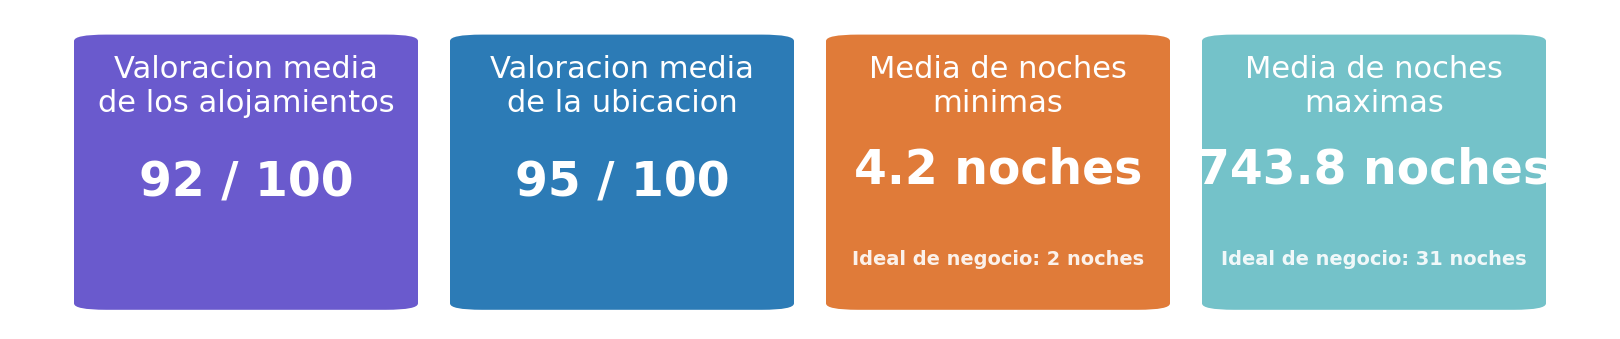

In [4]:
cards = [
    {'label': 'Valoracion media\nde los alojamientos',
     'valor': f'{media_rating:.0f} / 100',
     'sub':   None,
     'ideal': None,
     'color': ROJO},
    {'label': 'Valoracion media\nde la ubicacion',
     'valor': f'{media_location:.0f} / 100',
     'sub':   None,
     'ideal': None,
     'color': AZUL_PRINCIPAL},
    {'label': 'Media de noches\nminimas',
     'valor': f'{media_min:.1f} noches',
     'sub':   None,
     'ideal': 'Ideal de negocio: 2 noches',
     'color': NARANJA},
    {'label': 'Media de noches\nmaximas',
     'valor': f'{media_max:.1f} noches',
     'sub':   None,
     'ideal': 'Ideal de negocio: 31 noches',
     'color': TURQUESA},
]

fig, ax = plt.subplots(figsize=(16, 3.2))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

n, gap = len(cards), 0.06
w = (1 - (n + 1) * gap) / n

for i, card in enumerate(cards):
    x  = gap + i * (w + gap)
    cx = x + w / 2

    fig.add_artist(mpatches.FancyBboxPatch(
        (x, 0.08), w, 0.82, boxstyle='round,pad=0.02',
        transform=fig.transFigure, facecolor=card['color'],
        edgecolor='none', clip_on=False, zorder=2
    ))

    # Etiqueta superior
    fig.text(cx, 0.76, card['label'], ha='center', va='center',
             fontsize=22, color='white', transform=fig.transFigure, zorder=3)

    # Número principal — centrado verticalmente si no hay ideal
    y_valor = 0.50 if card['ideal'] else 0.46
    fig.text(cx, y_valor, card['valor'], ha='center', va='center',
             fontsize=34, fontweight='bold', color='white',
             transform=fig.transFigure, zorder=3)

    # Ideal de negocio — fuente reducida a 14
    if card['ideal']:
        fig.text(cx, 0.22, card['ideal'], ha='center', va='center',
                 fontsize=14, fontweight='bold', color=(1, 1, 1, 0.9),
                 transform=fig.transFigure, zorder=3)

plt.tight_layout(pad=0)
#plt.savefig(f'{OUTPUT_DIR}/fig1_cards.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Las cards muestran el estado actual del mercado. Los alojamientos tienen buena valoración (91.9/100) y excelente location score (95.4/100). Sin embargo, la política de noches revela un desajuste: la media de noches mínimas es 4.2 cuando el ideal es 2, y la media de noches máximas es 743.8 cuando el ideal turístico es 31.

## Fig 2 — Distancia media global al ideal por dimensión

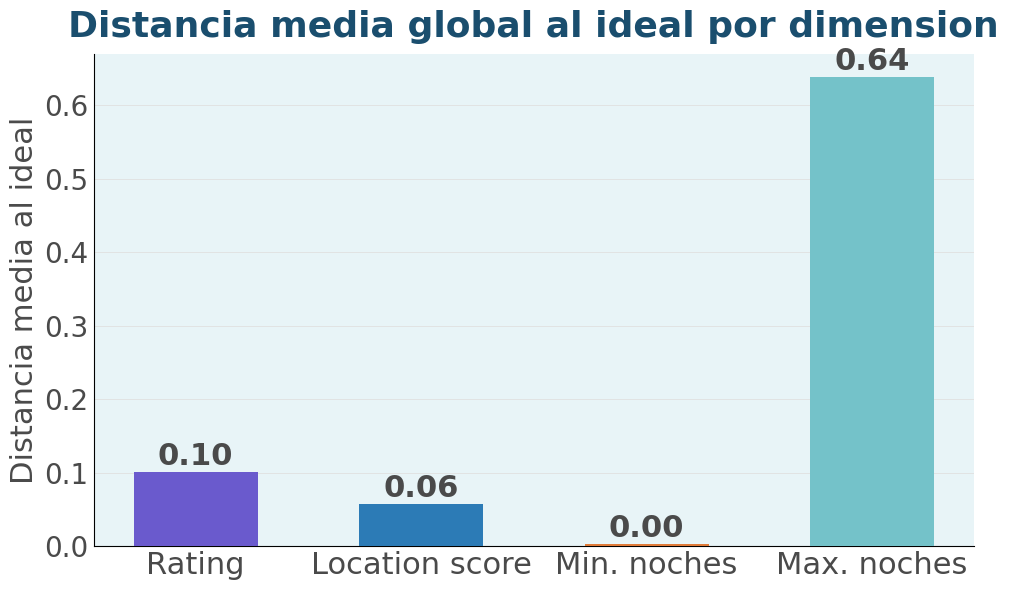

In [5]:
COLORES_DIST = [ROJO, AZUL_PRINCIPAL, NARANJA, TURQUESA]
LABELS_DIST  = ['Rating', 'Location score', 'Min. noches', 'Max. noches']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(LABELS_DIST, medias_dist.values,
              color=COLORES_DIST, width=0.55, zorder=3)

for bar, val in zip(bars, medias_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=22, fontweight='bold', color=GRIS_TEXTO)

ax.set_ylabel('Distancia media al ideal', fontsize=22, color=GRIS_TEXTO)
ax.set_title('Distancia media global al ideal por dimension',
             fontsize=26, fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', length=0, labelsize=22, colors=GRIS_TEXTO)
ax.tick_params(axis='y', labelsize=20, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig2_distancias_globales.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

La distancia en noches máximas (0.638) es 6 veces mayor que la del rating (0.101) y domina completamente el análisis. Incluirla en el ranking de ciudades y barrios haría que todas parecieran igual de problemáticas, ocultando diferencias reales. Por esa razón se excluye `dist_max_nights` del análisis comparativo.

## Fig 3 — Potencial por ciudad con 4 dimensiones (contexto)

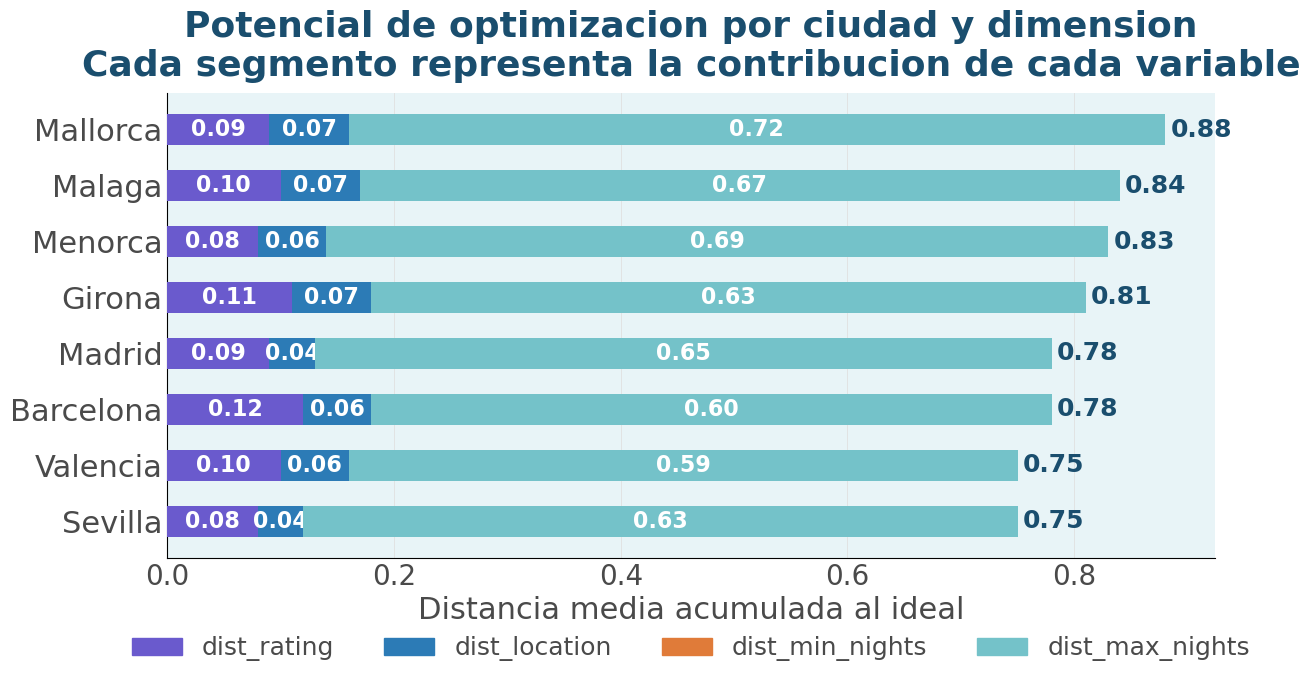

In [6]:
dist_cols_4 = ['dist_rating', 'dist_location', 'dist_min_nights', 'dist_max_nights']
ciudad_stacked = (df.groupby('city')[dist_cols_4]
                  .mean().round(2).reset_index())
ciudad_stacked['total'] = ciudad_stacked[dist_cols_4].sum(axis=1).round(2)
ciudad_stacked = ciudad_stacked.sort_values('total', ascending=True)
ciudades = ciudad_stacked['city'].str.capitalize().tolist()
COLORES4 = [ROJO, AZUL_PRINCIPAL, NARANJA, TURQUESA]
lefts    = [0] * len(ciudad_stacked)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

for col, color in zip(dist_cols_4, COLORES4):
    vals = ciudad_stacked[col].values
    bars = ax.barh(ciudades, vals, left=lefts,
                   color=color, height=0.55, zorder=3)
    for bar, val, left in zip(bars, vals, lefts):
        if val > 0.01:
            ax.text(left + val / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
    lefts = [l + v for l, v in zip(lefts, vals)]

for i, (total, ciudad) in enumerate(zip(ciudad_stacked['total'], ciudades)):
    ax.text(total + 0.005, i, f'{total:.2f}', ha='left', va='center',
            fontsize=18, fontweight='bold', color=AZUL_OSCURO)

legend_handles = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(COLORES4, ['dist_rating', 'dist_location',
                                              'dist_min_nights', 'dist_max_nights'])]

# ── Leyenda debajo del gráfico ────────────────────────────────────────────────
ax.legend(handles=legend_handles, frameon=False, fontsize=18,
          labelcolor=GRIS_TEXTO,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.12),
          ncol=4)

titulo    = 'Potencial de optimizacion por ciudad y dimension'
subtitulo = 'Cada segmento representa la contribucion de cada variable'
ax.set_xlabel('Distancia media acumulada al ideal', fontsize=22, color=GRIS_TEXTO)
ax.set_title(f'{titulo}\n{subtitulo}',
             fontsize=26, fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=22, colors=GRIS_TEXTO)
ax.tick_params(axis='x', labelsize=20, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig3_ciudades_4d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico confirma visualmente por qué `dist_max_nights` debe excluirse: la barra turquesa domina en todas las ciudades por igual, haciendo imposible distinguir cuál tiene más potencial real de mejora. Mallorca lidera con 0.878 pero prácticamente toda esa distancia proviene de las noches máximas.

## Fig 4 — Ranking de ciudades con 3 dimensiones (análisis principal)

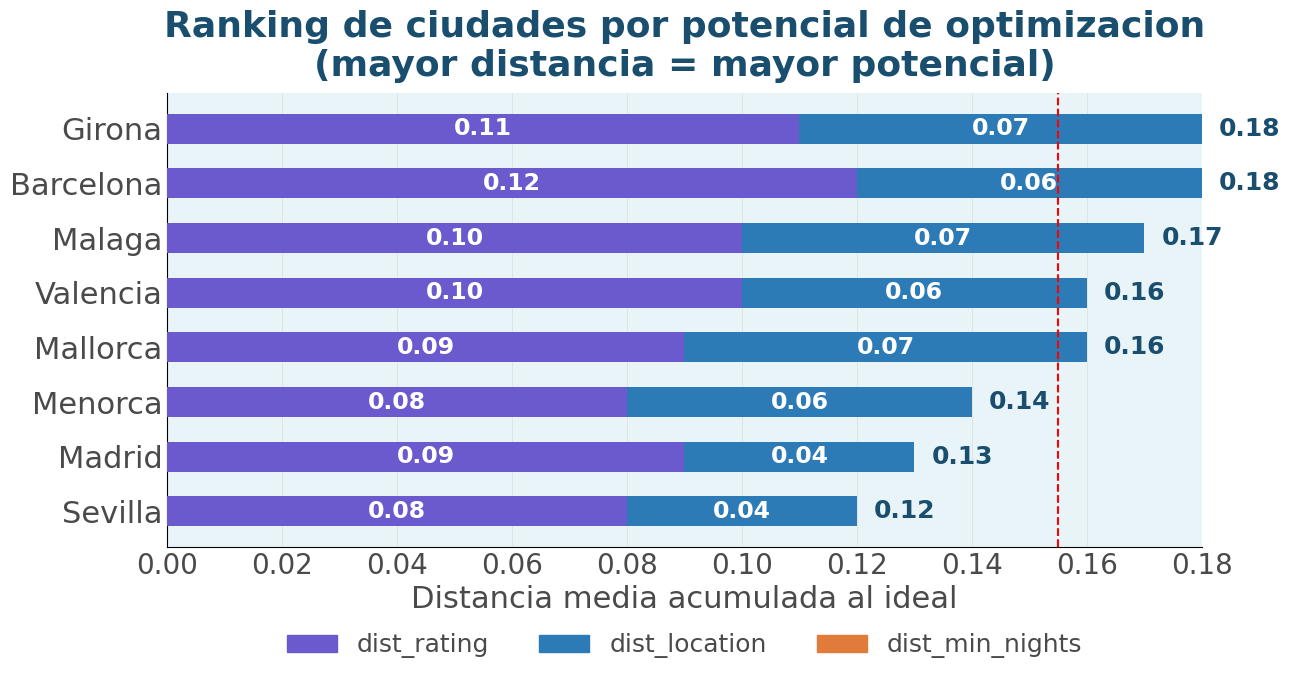

In [7]:
dist_cols_3 = ['dist_rating', 'dist_location', 'dist_min_nights']
COLORES3    = [ROJO, AZUL_PRINCIPAL, NARANJA]

ciudad_3d = (df.groupby('city')[dist_cols_3]
             .mean().round(2).reset_index())
ciudad_3d['total_3d'] = ciudad_3d[dist_cols_3].sum(axis=1).round(2)
ciudad_3d = ciudad_3d.sort_values('total_3d', ascending=True)

ciudades_3d = ciudad_3d['city'].str.capitalize().tolist()
lefts       = [0] * len(ciudad_3d)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

for col, color in zip(dist_cols_3, COLORES3):
    vals = ciudad_3d[col].values
    bars = ax.barh(ciudades_3d, vals, left=lefts,
                   color=color, height=0.55, zorder=3)
    for bar, val, left in zip(bars, vals, lefts):
        if val > 0.005:
            ax.text(left + val / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', ha='center', va='center',
                    fontsize=17, fontweight='bold', color='white')
    lefts = [l + v for l, v in zip(lefts, vals)]

media_global_3d = ciudad_3d['total_3d'].mean()
ax.axvline(media_global_3d, color='red', linewidth=1.5, linestyle='--',
           label=f'Media global: {media_global_3d:.2f}', zorder=4)

# ── Etiqueta total sin la palabra "Total:" ────────────────────────────────────
for i, (total, ciudad) in enumerate(zip(ciudad_3d['total_3d'], ciudades_3d)):
    ax.text(total + 0.003, i, f'{total:.2f}', ha='left', va='center',
            fontsize=18, fontweight='bold', color=AZUL_OSCURO)

legend_handles = [
    mpatches.Patch(color=ROJO,           label='dist_rating'),
    mpatches.Patch(color=AZUL_PRINCIPAL, label='dist_location'),
    mpatches.Patch(color=NARANJA,        label='dist_min_nights'),
]

# ── Leyenda debajo del gráfico ────────────────────────────────────────────────
ax.legend(handles=legend_handles, frameon=False, fontsize=18,
          labelcolor=GRIS_TEXTO,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.14),
          ncol=3)

xlabel    = 'Distancia media acumulada al ideal'

titulo    = 'Ranking de ciudades por potencial de optimizacion'
subtitulo = '(mayor distancia = mayor potencial)'

ax.set_xlabel(f'{xlabel}', fontsize=22, color=GRIS_TEXTO)
ax.set_title(f'{titulo}\n{subtitulo}',
             fontsize=26, fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=22, colors=GRIS_TEXTO)
ax.tick_params(axis='x', labelsize=20, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig4_ranking_ciudades_3d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Con las noches máximas excluidas el ranking cambia y se vuelve accionable. Girona (0.181) y Barcelona (0.178) son las ciudades con mayor potencial — sus alojamientos están más lejos del ideal en calidad y ubicación. Sevilla (0.122) y Madrid (0.139) son las más cercanas al ideal.

## Fig 5 — Top 10 barrios con mayor potencial de optimización

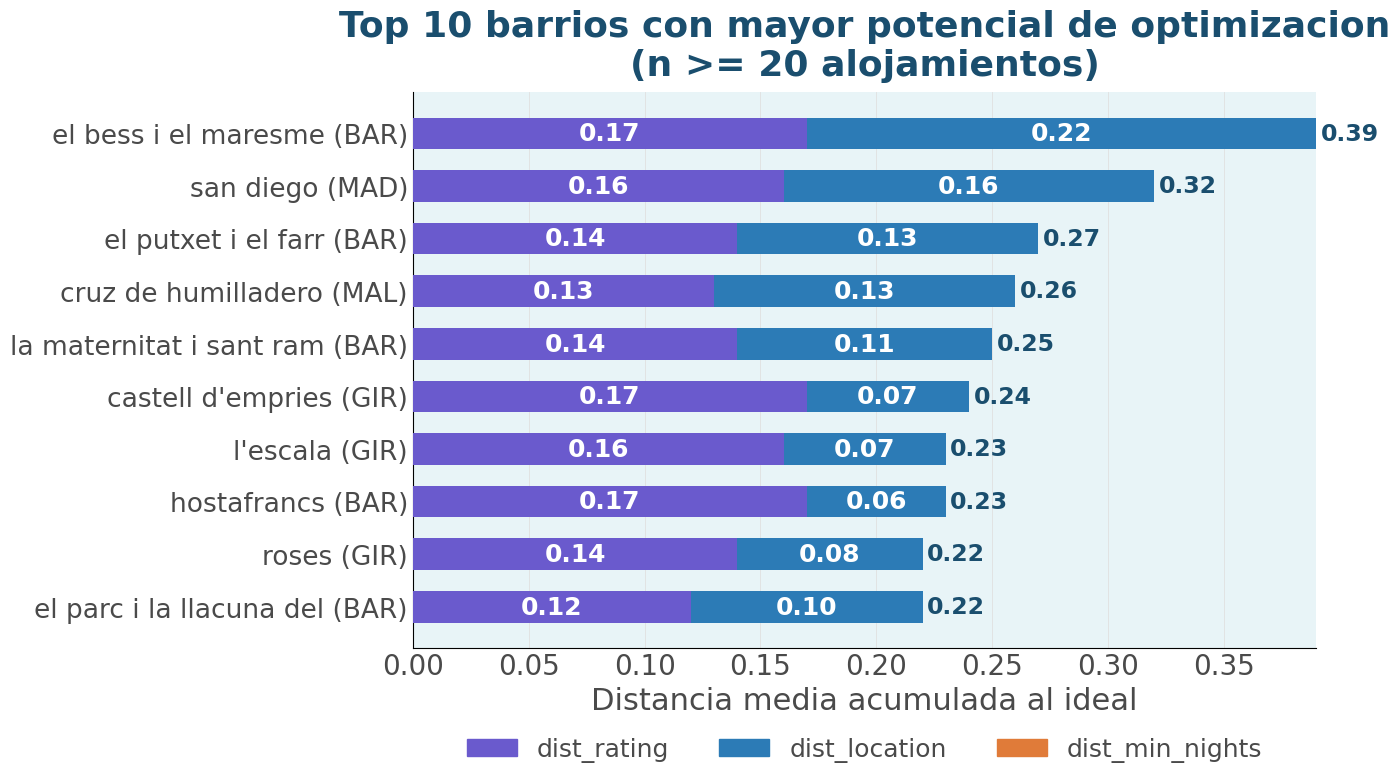

In [8]:
barrio_stacked = (df.groupby(['city', 'neighbourhood_name_clean'])
                  .agg(
                      n               = ('dist_total',      'count'),
                      dist_rating     = ('dist_rating',     'mean'),
                      dist_location   = ('dist_location',   'mean'),
                      dist_min_nights = ('dist_min_nights', 'mean'),
                  ).round(2).reset_index())

barrio_stacked = barrio_stacked[barrio_stacked['n'] >= MIN_N].copy()
barrio_stacked['total_3d'] = barrio_stacked[dist_cols_3].sum(axis=1).round(2)
barrio_stacked = barrio_stacked.sort_values('total_3d', ascending=True)

top10  = barrio_stacked.tail(10).copy()
labels = [f"{r['neighbourhood_name_clean'][:24]} ({r['city'][:3].upper()})"
          for _, r in top10.iterrows()]
lefts  = [0] * len(top10)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

for col, color in zip(dist_cols_3, COLORES3):
    vals = top10[col].values
    bars = ax.barh(labels, vals, left=lefts,
                   color=color, height=0.6, zorder=3)
    for bar, val, left in zip(bars, vals, lefts):
        if val > 0.005:
            ax.text(left + val / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', ha='center', va='center',
                    fontsize=18, fontweight='bold', color='white')
    lefts = [l + v for l, v in zip(lefts, vals)]

# ── Etiqueta total sin la palabra "Total:" ────────────────────────────────────
for i, (total, label) in enumerate(zip(top10['total_3d'], labels)):
    ax.text(total + 0.002, i, f'{total:.2f}', ha='left', va='center',
            fontsize=17, fontweight='bold', color=AZUL_OSCURO)

legend_handles = [
    mpatches.Patch(color=ROJO,           label='dist_rating'),
    mpatches.Patch(color=AZUL_PRINCIPAL, label='dist_location'),
    mpatches.Patch(color=NARANJA,        label='dist_min_nights'),
]

# ── Leyenda debajo del gráfico ────────────────────────────────────────────────
ax.legend(handles=legend_handles, frameon=False, fontsize=18,
          labelcolor=GRIS_TEXTO,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.12),
          ncol=3)

xlabel    = 'Distancia media acumulada al ideal'

titulo    = 'Top 10 barrios con mayor potencial de optimizacion'
subtitulo = '(n >= 20 alojamientos)'

ax.set_xlabel(f'{xlabel}', fontsize=22, color=GRIS_TEXTO)
ax.set_title(f'{titulo}\n{subtitulo}',
             fontsize=26, fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=19, colors=GRIS_TEXTO)
ax.tick_params(axis='x', labelsize=20, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig5_top10_barrios.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

El Besòs i el Maresme (Barcelona) lidera con 0.392 — su problema principal es la ubicación (0.221). San Diego (Madrid) es segundo con 0.329, con problema equilibrado entre calidad y ubicación. Cada barrio tiene un perfil diferente que permite diseñar acciones específicas.

## Fig 6 — Top 5 barrios por calidad y por ubicación

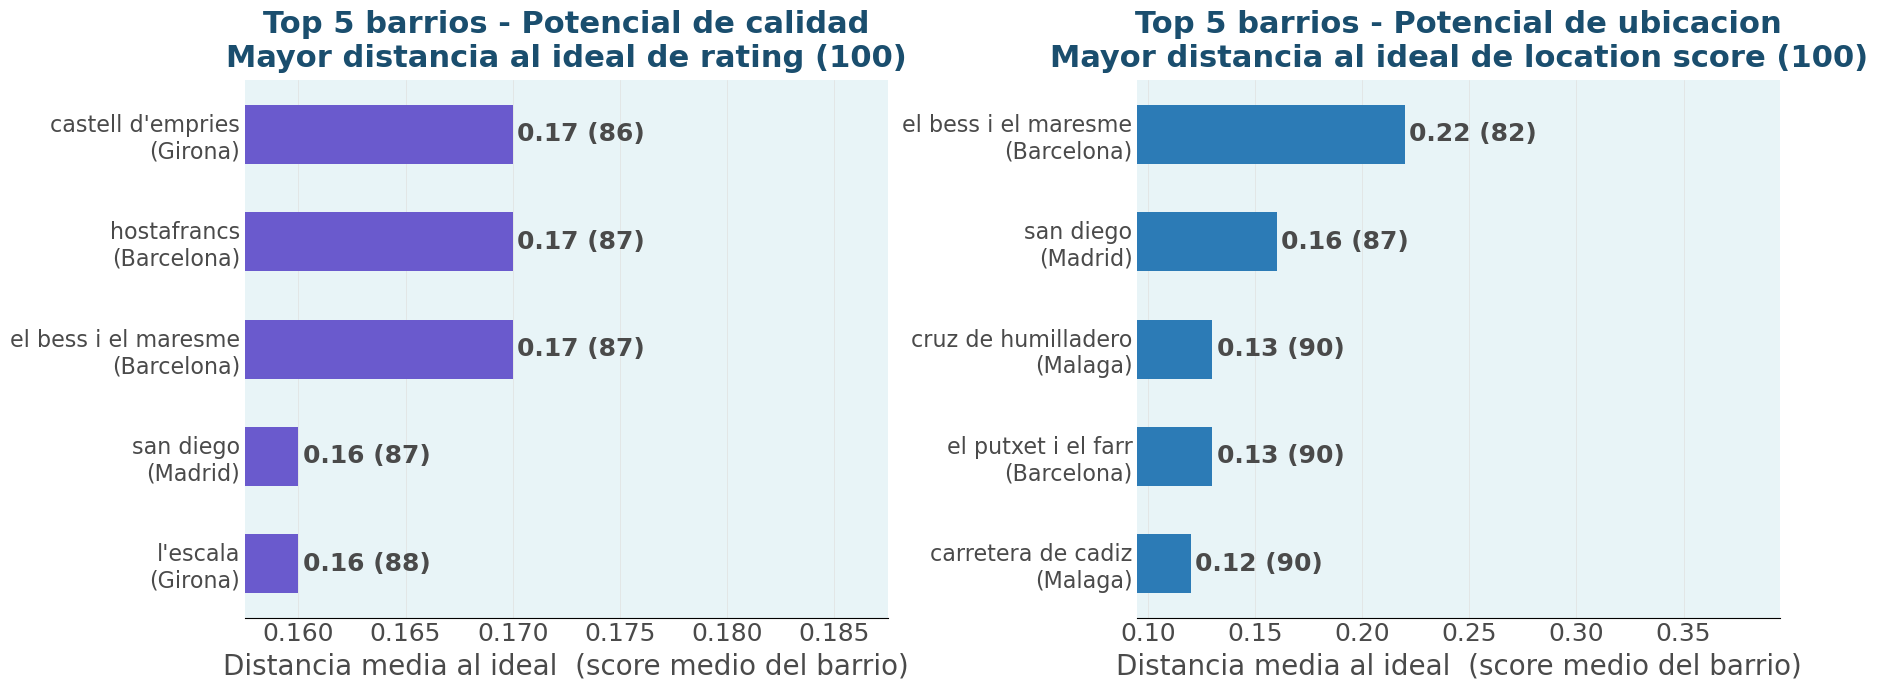

In [9]:
barrio_top = (df.groupby(['city', 'neighbourhood_name_clean'])
              .agg(
                  n                    = ('dist_rating',               'count'),
                  dist_rating          = ('dist_rating',               'mean'),
                  dist_location        = ('dist_location',             'mean'),
                  rating_medio         = ('review_scores_rating_clean', 'mean'),
                  location_medio       = ('review_scores_location',     'mean'),
              ).round(2).reset_index())

barrio_top = barrio_top[barrio_top['n'] >= MIN_N].copy()

top5_rating   = barrio_top.nlargest(5, 'dist_rating').sort_values('dist_rating',   ascending=True)
top5_location = barrio_top.nlargest(5, 'dist_location').sort_values('dist_location', ascending=True)

# ── Etiquetas solo con nombre + ciudad (sin score) ────────────────────────────
labels_rating = [
    f"{r['neighbourhood_name_clean'][:22]}\n({r['city'].capitalize()})"
    for _, r in top5_rating.iterrows()
]
labels_location = [
    f"{r['neighbourhood_name_clean'][:22]}\n({r['city'].capitalize()})"
    for _, r in top5_location.iterrows()
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

configs = [
    (axes[0], top5_rating,   labels_rating,   'dist_rating',   'rating_medio',
     ROJO,
     'Top 5 barrios - Potencial de calidad',
     'Mayor distancia al ideal de rating (100)'),
    (axes[1], top5_location, labels_location, 'dist_location', 'location_medio',
     AZUL_PRINCIPAL,
     'Top 5 barrios - Potencial de ubicacion',
     'Mayor distancia al ideal de location score (100)'),
]

for ax, top5, labels, col, col_score, color, titulo, subtitulo in configs:
    ax.set_facecolor(FONDO_SUAVE)
    bars = ax.barh(labels, top5[col].values, color=color, height=0.55, zorder=3)

    rng = top5[col].max() - top5[col].min()

    # ── Distancia + score entre paréntesis al lado de la barra ───────────────
    for bar, val, score in zip(bars, top5[col].values, top5[col_score].values):
        ax.text(bar.get_width() + rng * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f} ({score:.0f})',
                va='center', fontsize=18,
                fontweight='bold', color=GRIS_TEXTO)

    margen = rng * 0.25 if rng > 0 else top5[col].max() * 0.1
    ax.set_xlim(max(0, top5[col].min() - margen),
                top5[col].max() + margen * 7)

    ax.set_title(f'{titulo}\n{subtitulo}',
                 fontsize=22, fontweight='bold', color=AZUL_OSCURO, pad=10)
    ax.set_xlabel('Distancia media al ideal  (score medio del barrio)',
                  fontsize=20, color=GRIS_TEXTO)
    ax.xaxis.grid(True, linestyle='-', linewidth=0.5, color=GRIS_GRID, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='y', length=0, labelsize=16, colors=GRIS_TEXTO)
    ax.tick_params(axis='x', length=0, labelsize=18, colors=GRIS_TEXTO)

plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig6_top5_rating_location.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

A la izquierda, los barrios con peor calidad percibida — Castelló d'Empúries (Girona) lidera con 0.171. La acción recomendada es asesoramiento a propietarios. A la derecha, los barrios con peor valoración de ubicación — El Besòs i el Maresme (Barcelona) lidera con 0.221. La acción recomendada es comunicar el valor del entorno y destacar puntos de interés cercanos.

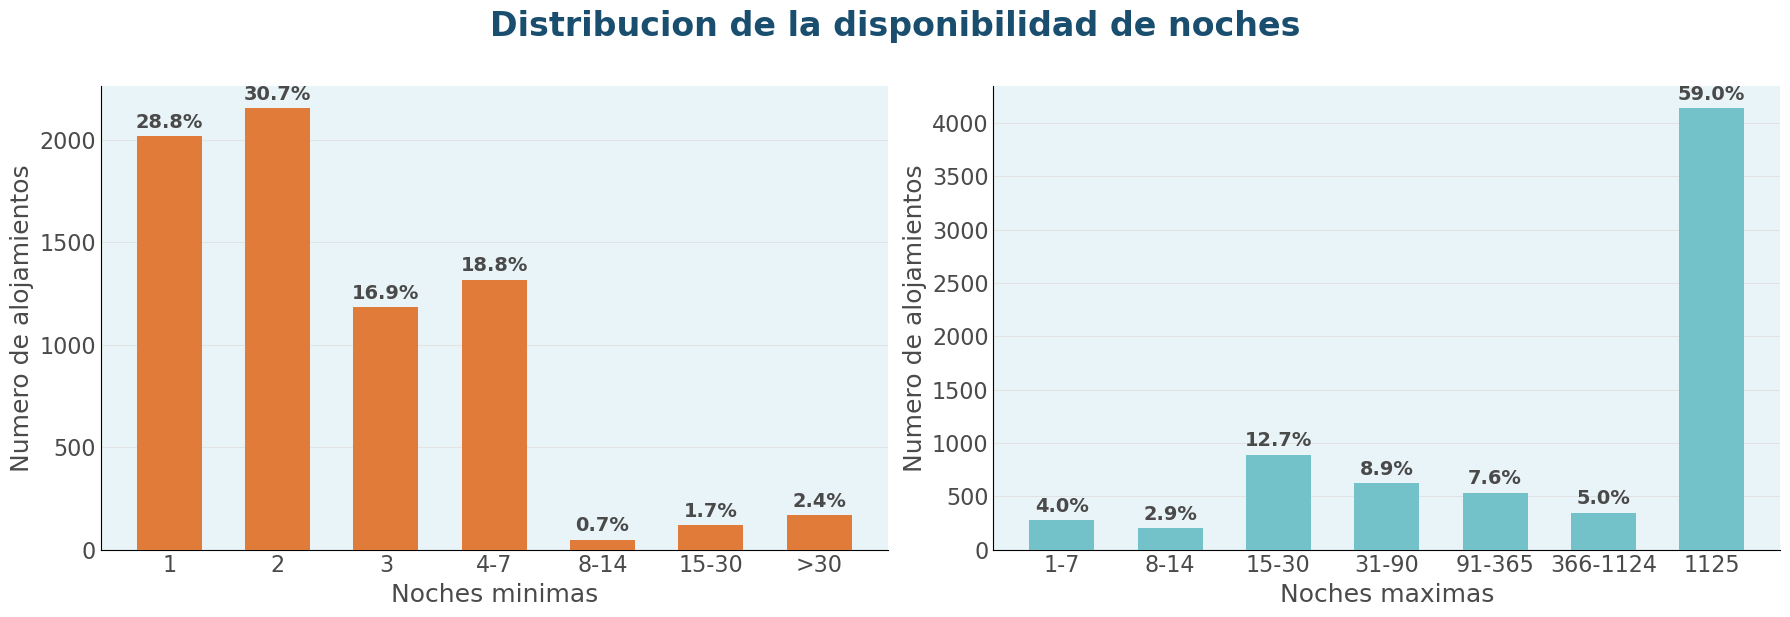

In [10]:
bins_min   = [0, 1, 2, 3, 7, 14, 30, float('inf')]
labels_min = ['1', '2', '3', '4-7', '8-14', '15-30', '>30']

df['min_nights_grupo'] = pd.cut(df['minimum_nights'],
                                 bins=bins_min,
                                 labels=labels_min,
                                 right=True)

count_min = df['min_nights_grupo'].value_counts().sort_index()
pct_min   = (count_min / count_min.sum() * 100).round(1)

bins_max   = [0, 7, 14, 30, 90, 365, 1124, float('inf')]
labels_max = ['1-7', '8-14', '15-30', '31-90', '91-365', '366-1124', '1125']

df['max_nights_grupo'] = pd.cut(df['maximum_nights'],
                                 bins=bins_max,
                                 labels=labels_max,
                                 right=True)

count_max = df['max_nights_grupo'].value_counts().sort_index()
pct_max   = (count_max / count_max.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

# ── Subplot 1: minimum_nights ─────────────────────────────────────────────────
axes[0].set_facecolor(FONDO_SUAVE)

bars_min = axes[0].bar(count_min.index.astype(str), count_min.values,
                       color=NARANJA, width=0.6, zorder=3)

for bar, pct in zip(bars_min, pct_min.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + count_min.max() * 0.01,
                 f'{pct:.1f}%',
                 ha='center', va='bottom',
                 fontsize=14, fontweight='bold', color=GRIS_TEXTO)

axes[0].set_xlabel('Noches minimas', fontsize=18, color=GRIS_TEXTO)
axes[0].set_ylabel('Numero de alojamientos', fontsize=18, color=GRIS_TEXTO)
axes[0].yaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
axes[0].set_axisbelow(True)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)
axes[0].tick_params(axis='x', length=0, labelsize=16, colors=GRIS_TEXTO)
axes[0].tick_params(axis='y', labelsize=16, colors=GRIS_TEXTO, length=0)

# ── Subplot 2: maximum_nights ─────────────────────────────────────────────────
axes[1].set_facecolor(FONDO_SUAVE)

# ── Todas las barras en turquesa, sin leyenda ─────────────────────────────────
bars_max = axes[1].bar(count_max.index.astype(str), count_max.values,
                       color=TURQUESA, width=0.6, zorder=3)

for bar, pct in zip(bars_max, pct_max.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + count_max.max() * 0.01,
                 f'{pct:.1f}%',
                 ha='center', va='bottom',
                 fontsize=14, fontweight='bold', color=GRIS_TEXTO)

axes[1].set_xlabel('Noches maximas', fontsize=18, color=GRIS_TEXTO)
axes[1].set_ylabel('Numero de alojamientos', fontsize=18, color=GRIS_TEXTO)
axes[1].yaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
axes[1].set_axisbelow(True)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)
axes[1].tick_params(axis='x', length=0, labelsize=16, colors=GRIS_TEXTO)
axes[1].tick_params(axis='y', labelsize=16, colors=GRIS_TEXTO, length=0)

plt.suptitle('Distribucion de la disponibilidad de noches',
             fontsize=24, fontweight='bold', color=AZUL_OSCURO, y=1.02)
plt.tight_layout()
#plt.savefig(f'{OUTPUT_DIR}/fig7_dist_noches.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()